C1: (2048, 2448, 3)   C2: (2048, 2448, 3)


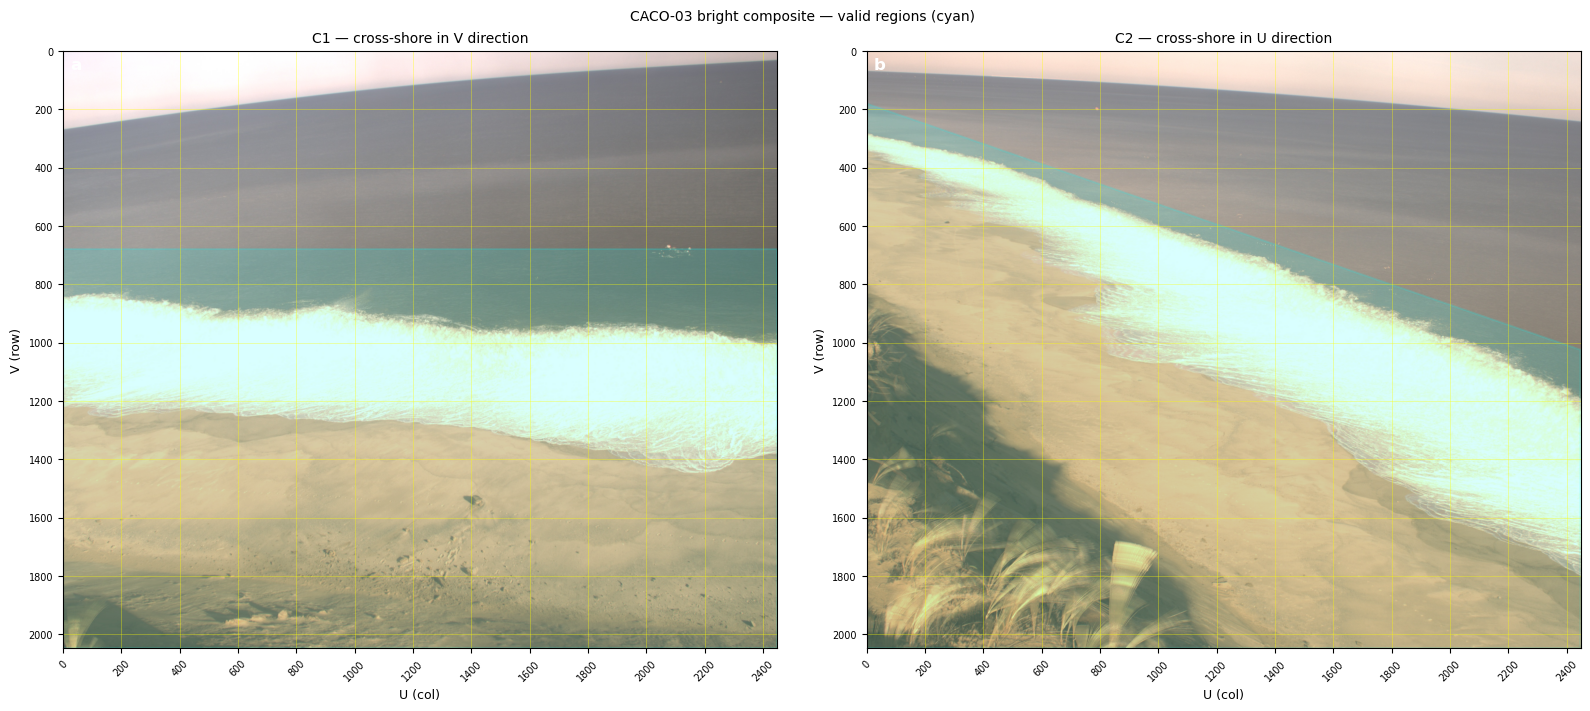

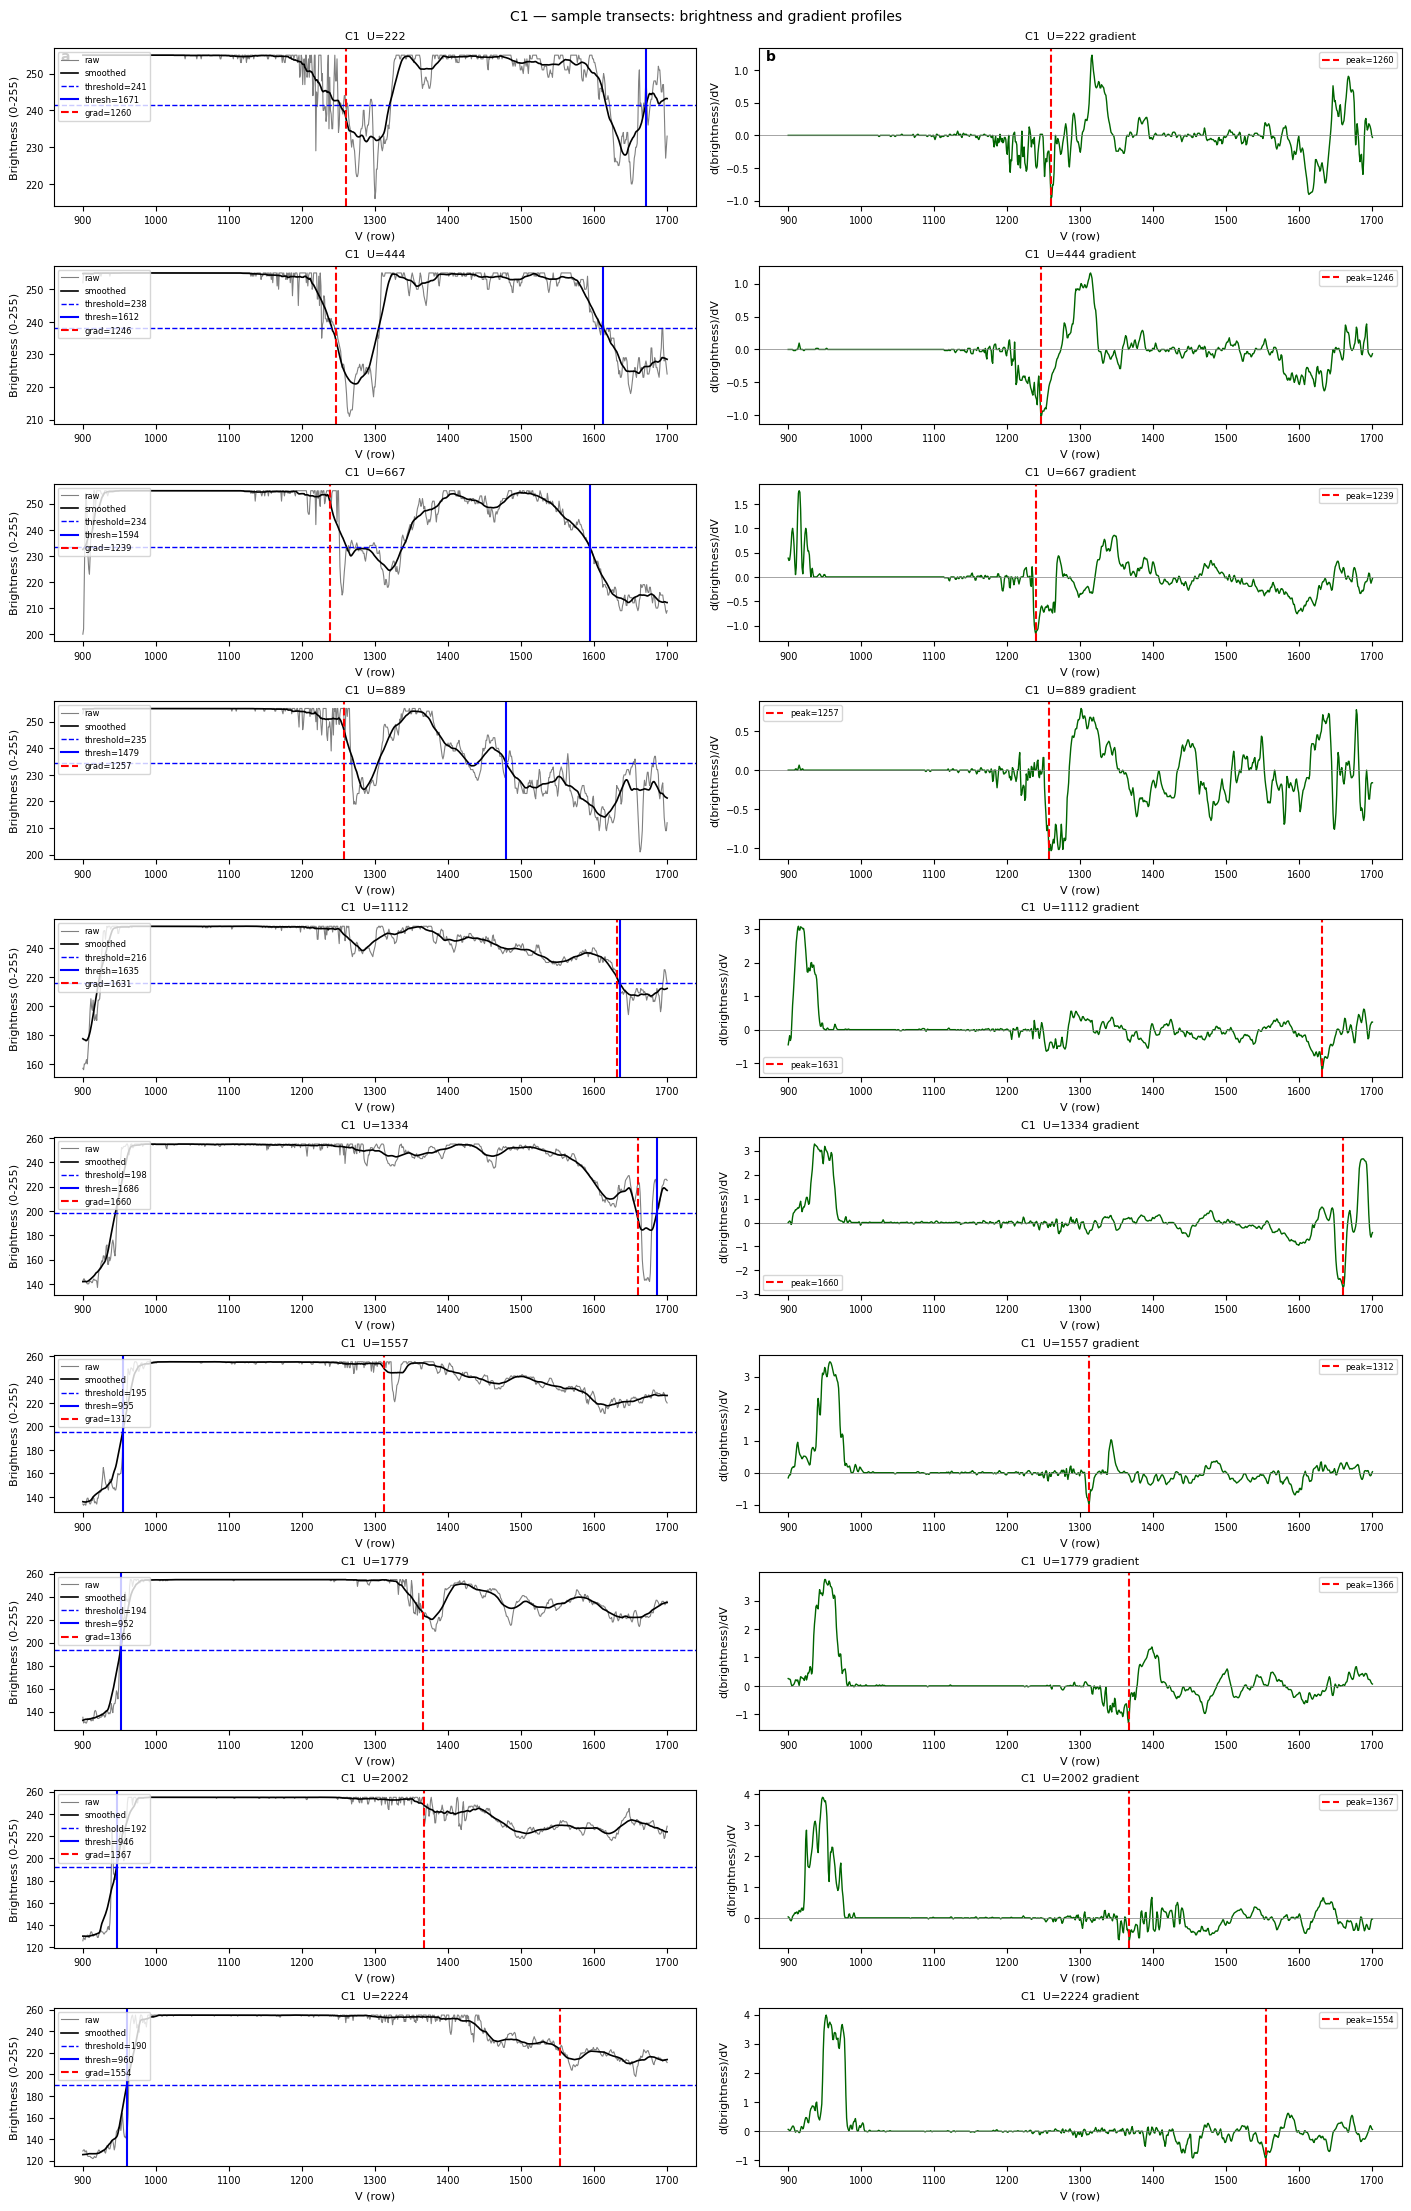

Saved: c1_transects.png


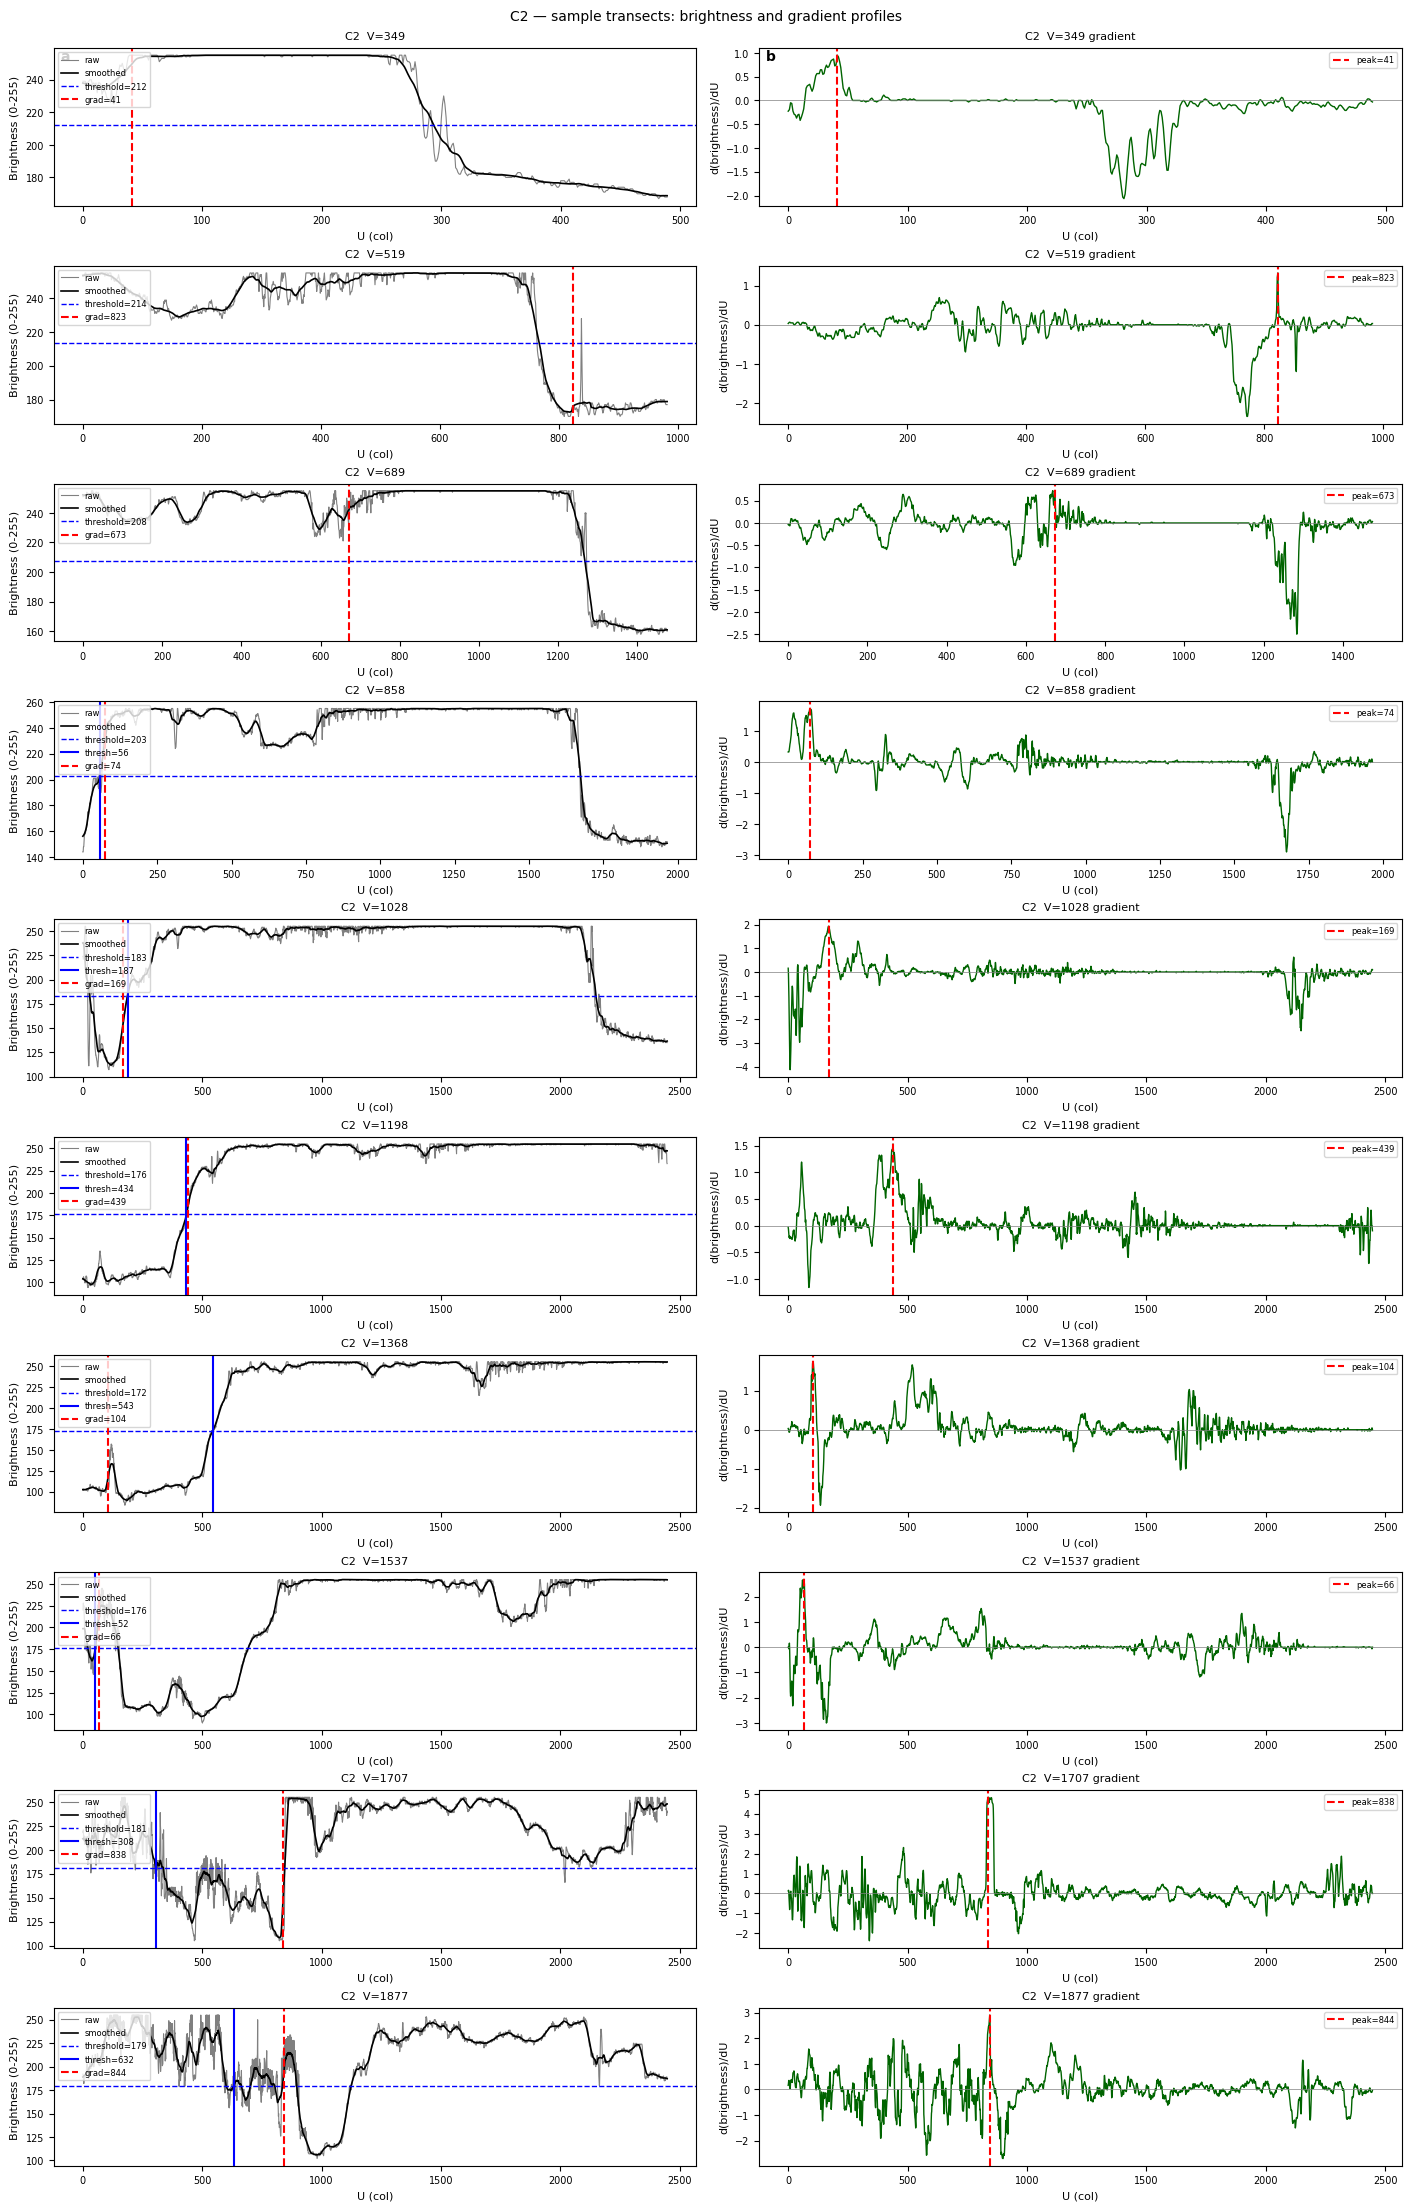

Saved: c2_transects.png


<Figure size 640x480 with 0 Axes>

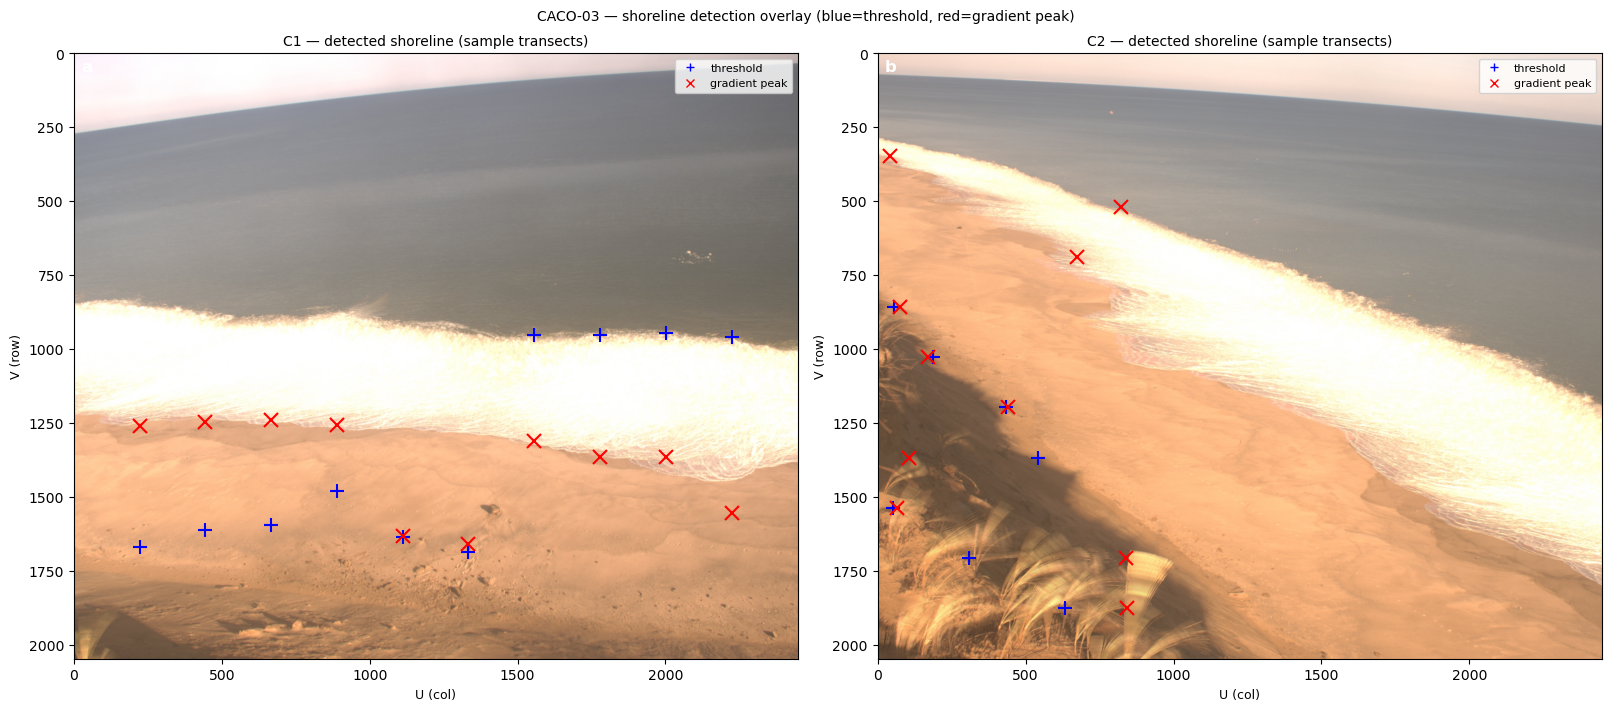


C1 results:
  U= 222  thresh_V=1670.9  grad_V=1260.0
  U= 444  thresh_V=1612.4  grad_V=1246.0
  U= 667  thresh_V=1594.0  grad_V=1239.0
  U= 889  thresh_V=1479.3  grad_V=1257.0
  U=1112  thresh_V=1635.2  grad_V=1631.0
  U=1334  thresh_V=1685.8  grad_V=1660.0
  U=1557  thresh_V=954.6  grad_V=1312.0
  U=1779  thresh_V=951.6  grad_V=1366.0
  U=2002  thresh_V=946.2  grad_V=1367.0
  U=2224  thresh_V=960.2  grad_V=1554.0

C2 results:
  V= 349  thresh_U=nan  grad_U=41.0
  V= 519  thresh_U=nan  grad_U=823.0
  V= 689  thresh_U=nan  grad_U=673.0
  V= 858  thresh_U=56.3  grad_U=74.0
  V=1028  thresh_U=187.3  grad_U=169.0
  V=1198  thresh_U=433.6  grad_U=439.0
  V=1368  thresh_U=543.2  grad_U=104.0
  V=1537  thresh_U=51.6  grad_U=66.0
  V=1707  thresh_U=308.0  grad_U=838.0
  V=1877  thresh_U=632.2  grad_U=844.0


In [1]:
# csherwood@usgs.gov, 2026-06-12, generated with Claude Sonnet 4.6
# Shoreline detection from bright (brightest-pixel composite) images
# Step 1: Grid display and polygon definition
# Step 2: Sample transects and shoreline detection (threshold + gradient peak)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from PIL import Image
from scipy.ndimage import uniform_filter1d
from scipy.signal import find_peaks

# ── Configuration ─────────────────────────────────────────────────────────────
C1_IMG = r"F:\crs\proj\marconi_imagery\caco-03\c1\2024\353_Dec.18\1734543000.Wed.Dec.18_17_30_00.GMT.2024.CACO03.c1.bright.jpg"
C2_IMG = r"F:\crs\proj\marconi_imagery\caco-03\c2\2024\353_Dec.18\1734543000.Wed.Dec.18_17_30_00.GMT.2024.CACO03.c2.bright.jpg"

GRID_SPACING  = 200   # px between grid lines
N_TRANSECTS   = 10    # sample transects for diagnostics
SMOOTH_PX     = 15    # uniform filter half-width (px) for brightness smoothing

# C1: transects are constant-U vertical lines; cross-shore = V direction
# Shoreline near V=1200-1400; land at higher V
C1_POLYGON = np.array([
    [   0,  680],
    [2447,  680],
    [2447, 2047],
    [   0, 2047],
])  # (U, V) vertices

# C1 search window in V (rows) — broad enough to bracket expected shoreline
C1_V_MIN, C1_V_MAX = 900, 1700

# C2: transects are constant-V horizontal lines; cross-shore = U direction
# Shoreline runs diagonally; land at lower U
# Valid region is below the line from (0, 180) to (2447, 1024)
C2_POLYGON = np.array([
    [   0,  180],
    [2447, 1024],
    [2447, 2047],
    [   0, 2047],
])  # (U, V) vertices

# C2 search window in U (cols) — broad; will be further clipped by polygon boundary
C2_U_MIN, C2_U_MAX = 0, 2447

# ── Load images ───────────────────────────────────────────────────────────────
c1 = np.array(Image.open(C1_IMG))
c2 = np.array(Image.open(C2_IMG))
print(f"C1: {c1.shape}   C2: {c2.shape}")


# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Grid display
# ═══════════════════════════════════════════════════════════════════════════════
def plot_image_with_grid(ax, img, title, grid_spacing=GRID_SPACING):
    H, W = img.shape[:2]
    ax.imshow(img, origin='upper')
    ax.set_xticks(np.arange(0, W, grid_spacing))
    ax.set_yticks(np.arange(0, H, grid_spacing))
    ax.set_xticklabels(np.arange(0, W, grid_spacing), fontsize=7, rotation=45)
    ax.set_yticklabels(np.arange(0, H, grid_spacing), fontsize=7)
    ax.grid(color='yellow', linewidth=0.4, alpha=0.6)
    ax.set_xlabel("U (col)", fontsize=9)
    ax.set_ylabel("V (row)", fontsize=9)
    ax.set_title(title, fontsize=10)

def overlay_polygon(ax, poly_uv, color='cyan'):
    patch = MplPolygon(poly_uv, closed=True,
                       edgecolor=color, facecolor=color, alpha=0.15, linewidth=1.5)
    ax.add_patch(patch)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
plot_image_with_grid(axes[0], c1, "C1 — cross-shore in V direction")
overlay_polygon(axes[0], C1_POLYGON)
plot_image_with_grid(axes[1], c2, "C2 — cross-shore in U direction")
overlay_polygon(axes[1], C2_POLYGON)
for ax, lbl in zip(axes, ['a', 'b']):
    ax.text(0.01, 0.99, lbl, transform=ax.transAxes, fontsize=12,
            fontweight='bold', color='white', va='top', ha='left')
plt.suptitle("CACO-03 bright composite — valid regions (cyan)", fontsize=10)
plt.savefig("caco03_polygons.png", dpi=150, bbox_inches='tight')
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Brightness extraction helpers
# ═══════════════════════════════════════════════════════════════════════════════
def rgb_to_value(rgb_strip):
    """HSV Value (brightness) from an (N, 3) uint8 RGB array. Returns float 0-255."""
    return rgb_strip.max(axis=1).astype(float)

def c2_u_max_at_v(v):
    """For C2: return maximum valid U at a given V row (seaward boundary line).
    Line runs from (U=0, V=180) to (U=2447, V=1024).
    Valid region is ABOVE this line (lower V), i.e. U < u_boundary at each V.
    Returns None if v < 180 (above the line's starting point)."""
    u0, v0 = 0,    180
    u1, v1 = 2447, 1024
    if v < v0:
        return None   # above valid region
    u_boundary = u0 + (u1 - u0) * (v - v0) / (v1 - v0)
    return int(np.clip(np.floor(u_boundary), 0, 2447))

def detect_shoreline(profile, coord, smooth_px=SMOOTH_PX, threshold=None,
                     search_from_high=False):
    """
    Detect shoreline in a 1-D brightness profile.

    Parameters
    ----------
    profile        : 1-D array of brightness values
    coord          : corresponding pixel coordinates (V for C1, U for C2)
    smooth_px      : smoothing kernel half-width in pixels
    threshold      : fixed brightness threshold (0-255); if None uses midpoint
    search_from_high : if True, search from the high-coord end (land side for C1,
                       where land is at high V). If False, search from low-coord
                       end (land side for C2, where land is at low U).

    Returns
    -------
    thresh_coord, grad_coord, profile_s, gradient, thresh_val
    """
    profile_s = uniform_filter1d(profile.astype(float), size=smooth_px*2+1)
    gradient  = np.gradient(profile_s, coord)

    if threshold is None:
        thresh_val = 0.5 * (profile_s.min() + profile_s.max())
    else:
        thresh_val = threshold

    above = profile_s >= thresh_val

    if search_from_high:
        # Search from high coord (land) toward low coord (ocean)
        # Find last index where we cross from below thresh to above thresh
        # i.e. first crossing when scanning in reverse
        crossings = np.where(np.diff(above.astype(int)) != 0)[0]
        # We want the crossing closest to the high-coord (land) end
        if len(crossings):
            idx = crossings[-1]   # last crossing = landward foam edge
            frac = (thresh_val - profile_s[idx]) / (profile_s[idx+1] - profile_s[idx] + 1e-9)
            thresh_coord = coord[idx] + frac * (coord[idx+1] - coord[idx])
        else:
            thresh_coord = np.nan
        # Gradient peak from land side: largest negative gradient (foam→sand, brightness drops)
        peaks, _ = find_peaks(-gradient, height=0)
        if len(peaks):
            best = peaks[np.argmax(-gradient[peaks])]
            grad_coord = coord[best]
        else:
            grad_coord = np.nan
    else:
        # Search from low coord (land) toward high coord (ocean)
        # Find first crossing from below thresh to above thresh
        crossings = np.where(np.diff(above.astype(int)) == 1)[0]
        if len(crossings):
            idx = crossings[0]
            frac = (thresh_val - profile_s[idx]) / (profile_s[idx+1] - profile_s[idx] + 1e-9)
            thresh_coord = coord[idx] + frac * (coord[idx+1] - coord[idx])
        else:
            thresh_coord = np.nan
        # Gradient peak: largest positive gradient (land→foam, brightness rises)
        peaks, _ = find_peaks(gradient, height=0)
        if len(peaks):
            best = peaks[np.argmax(gradient[peaks])]
            grad_coord = coord[best]
        else:
            grad_coord = np.nan

    return thresh_coord, grad_coord, profile_s, gradient, thresh_val


# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3 — C1 sample transects  (constant U, cross-shore = V)
# ═══════════════════════════════════════════════════════════════════════════════
def plot_transects(transects, xlabel, ylabel_bright, ylabel_grad, title, fname):
    """
    Plot brightness and gradient profiles for a list of transect dicts, each with keys:
      label, coord, profile, prof_s, grad, t_val, t_coord, g_coord
    Creates exactly as many rows as there are transects.
    """
    n = len(transects)
    fig, axes = plt.subplots(n, 2, figsize=(14, n * 2.2), constrained_layout=True,
                             squeeze=False)
    for i, tr in enumerate(transects):
        coord, profile, prof_s = tr['coord'], tr['profile'], tr['prof_s']
        grad, t_val = tr['grad'], tr['t_val']
        t_coord, g_coord = tr['t_coord'], tr['g_coord']

        ax = axes[i, 0]
        ax.plot(coord, profile, color='gray',  lw=0.8, label='raw')
        ax.plot(coord, prof_s,  color='black', lw=1.2, label='smoothed')
        ax.axhline(t_val, color='blue', lw=1, ls='--', label=f'threshold={t_val:.0f}')
        if not np.isnan(t_coord):
            ax.axvline(t_coord, color='blue', lw=1.5, label=f'thresh={t_coord:.0f}')
        if not np.isnan(g_coord):
            ax.axvline(g_coord, color='red',  lw=1.5, ls='--', label=f'grad={g_coord:.0f}')
        ax.set_xlabel(xlabel, fontsize=8)
        ax.set_ylabel(ylabel_bright, fontsize=8)
        ax.set_title(tr['label'], fontsize=8)
        ax.legend(fontsize=6, loc='upper left')
        ax.tick_params(labelsize=7)

        ax2 = axes[i, 1]
        ax2.plot(coord, grad, color='darkgreen', lw=1)
        ax2.axhline(0, color='gray', lw=0.5)
        if not np.isnan(g_coord):
            ax2.axvline(g_coord, color='red', lw=1.5, ls='--', label=f'peak={g_coord:.0f}')
        ax2.set_xlabel(xlabel, fontsize=8)
        ax2.set_ylabel(ylabel_grad, fontsize=8)
        ax2.set_title(tr['label'] + ' gradient', fontsize=8)
        ax2.legend(fontsize=6)
        ax2.tick_params(labelsize=7)

    axes[0, 0].text(0.01, 0.99, 'a', transform=axes[0, 0].transAxes,
                    fontsize=10, fontweight='bold', va='top')
    axes[0, 1].text(0.01, 0.99, 'b', transform=axes[0, 1].transAxes,
                    fontsize=10, fontweight='bold', va='top')
    plt.suptitle(title, fontsize=10)
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

# ── Collect C1 transects ──────────────────────────────────────────────────────
c1_sample_U = np.linspace(0, c1.shape[1]-1, N_TRANSECTS+2, dtype=int)[1:-1]
v_coords    = np.arange(C1_V_MIN, C1_V_MAX+1)

c1_results    = []   # detection results for overlay
c1_transects  = []   # full data for diagnostic plot

for u in c1_sample_U:
    profile = rgb_to_value(c1[C1_V_MIN:C1_V_MAX+1, u, :3])
    t_coord, g_coord, prof_s, grad, t_val = detect_shoreline(profile, v_coords,
                                                               search_from_high=True)
    c1_results.append(dict(U=u, thresh_V=t_coord, grad_V=g_coord))
    c1_transects.append(dict(label=f"C1  U={u}", coord=v_coords, profile=profile,
                             prof_s=prof_s, grad=grad, t_val=t_val,
                             t_coord=t_coord, g_coord=g_coord))

plot_transects(c1_transects,
               xlabel="V (row)", ylabel_bright="Brightness (0-255)",
               ylabel_grad="d(brightness)/dV",
               title="C1 — sample transects: brightness and gradient profiles",
               fname="c1_transects.png")


# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4 — C2 sample transects  (constant V, cross-shore = U)
# ═══════════════════════════════════════════════════════════════════════════════
c2_V_MIN_GLOBAL = 180
c2_sample_V = np.linspace(c2_V_MIN_GLOBAL, c2.shape[0]-1,
                           N_TRANSECTS+2, dtype=int)[1:-1]

c2_results   = []
c2_transects = []

for v in c2_sample_V:
    u_max = c2_u_max_at_v(v)
    if u_max is None or u_max < SMOOTH_PX*2:
        print(f"  skipping V={v}: valid U range too short (u_max={u_max})")
        continue
    u_coords = np.arange(0, u_max+1)
    profile  = rgb_to_value(c2[v, 0:u_max+1, :3])
    t_coord, g_coord, prof_s, grad, t_val = detect_shoreline(profile, u_coords,
                                                               search_from_high=False)
    c2_results.append(dict(V=v, thresh_U=t_coord, grad_U=g_coord))
    c2_transects.append(dict(label=f"C2  V={v}", coord=u_coords, profile=profile,
                             prof_s=prof_s, grad=grad, t_val=t_val,
                             t_coord=t_coord, g_coord=g_coord))

plot_transects(c2_transects,
               xlabel="U (col)", ylabel_bright="Brightness (0-255)",
               ylabel_grad="d(brightness)/dU",
               title="C2 — sample transects: brightness and gradient profiles",
               fname="c2_transects.png")

plt.suptitle("C2 — sample transects: brightness and gradient profiles", fontsize=10)

# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5 — Overlay detected shoreline points on images
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

# C1: points are (U, thresh_V) and (U, grad_V)
axes[0].imshow(c1, origin='upper')
for r in c1_results:
    if not np.isnan(r['thresh_V']):
        axes[0].plot(r['U'], r['thresh_V'], 'b+', ms=10, mew=1.5)
    if not np.isnan(r['grad_V']):
        axes[0].plot(r['U'], r['grad_V'],   'rx', ms=10, mew=1.5)
axes[0].plot([], [], 'b+', label='threshold')
axes[0].plot([], [], 'rx', label='gradient peak')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].set_xlabel("U (col)", fontsize=9)
axes[0].set_ylabel("V (row)", fontsize=9)
axes[0].set_title("C1 — detected shoreline (sample transects)", fontsize=10)

# C2: points are (thresh_U, V) and (grad_U, V)
axes[1].imshow(c2, origin='upper')
for r in c2_results:
    if not np.isnan(r['thresh_U']):
        axes[1].plot(r['thresh_U'], r['V'], 'b+', ms=10, mew=1.5)
    if not np.isnan(r['grad_U']):
        axes[1].plot(r['grad_U'],   r['V'], 'rx', ms=10, mew=1.5)
axes[1].plot([], [], 'b+', label='threshold')
axes[1].plot([], [], 'rx', label='gradient peak')
axes[1].legend(fontsize=8, loc='upper right')
axes[1].set_xlabel("U (col)", fontsize=9)
axes[1].set_ylabel("V (row)", fontsize=9)
axes[1].set_title("C2 — detected shoreline (sample transects)", fontsize=10)

for ax, lbl in zip(axes, ['a', 'b']):
    ax.text(0.01, 0.99, lbl, transform=ax.transAxes, fontsize=12,
            fontweight='bold', color='white', va='top', ha='left')

plt.suptitle("CACO-03 — shoreline detection overlay (blue=threshold, red=gradient peak)",
             fontsize=10)
plt.savefig("caco03_shoreline_overlay.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nC1 results:")
for r in c1_results:
    print(f"  U={r['U']:4d}  thresh_V={r['thresh_V']:.1f}  grad_V={r['grad_V']:.1f}")
print("\nC2 results:")
for r in c2_results:
    print(f"  V={r['V']:4d}  thresh_U={r['thresh_U']:.1f}  grad_U={r['grad_U']:.1f}")